In [275]:
import h5py
import numpy as np

In [276]:
import sys
sys.path.append('../')

In [277]:
h5_file = h5py.File('/home/fsoto/Documents/LCsSSL/data/detections_adquired.h5', 'r')

In [278]:
len(h5_file['training'])

70612

In [279]:
h5_file.keys()

<KeysViewHDF5 ['Multiband_period', 'err_tot', 'fid', 'labels', 'mag_tot', 'mask', 'oid', 'time', 'training', 'validation']>

In [280]:
classes = ["LPV", "RSCVn", "CEP", "EA", "EB/EW", "RRLc", "RRLab", "DSCT", "Periodic-Other"]

In [281]:
code_dict_inv = {
    0: "LPV",
    1: "RSCVn",
    2: "CEP",
    3: "EA",
    4: "EB/EW",
    5: "RRLc",
    6: "RRLab",
    7: "DSCT",
    8: "Periodic-Other",
}
important_classes = [2,3,4,5,6]

In [282]:
labels = h5_file['labels']

In [283]:
import pandas as pd

In [284]:
df  = pd.DataFrame(labels)
df.columns = ['label']
df['label'] = df['label'].apply(lambda x: code_dict_inv[x])


In [285]:
#remove the classes that are not important
df = df[df['label'].isin([code_dict_inv[x] for x in important_classes])]

In [286]:
import matplotlib.pyplot as plt
import seaborn as sns

In [287]:
#data 
h5_file.keys()

<KeysViewHDF5 ['Multiband_period', 'err_tot', 'fid', 'labels', 'mag_tot', 'mask', 'oid', 'time', 'training', 'validation']>

In [288]:
mags = h5_file['mag_tot']
times = h5_file['time']
errors = h5_file['err_tot']
masks = h5_file['mask']
labels = h5_file['labels']
periods = h5_file['Multiband_period']


In [289]:
import torch
def random_noise(time,mag,error,mask,period):
    noise_value = torch.normal(mean=0, std=0.5, size=mag.shape).float()
    #transform noise to numpy
    noise_value = noise_value.numpy()
    mag = mag + noise_value * error
    return time,mag,error,mask,period

In [290]:
def random_scaling(time, mag, error, mask, period):
    scale = 0.05  # Default scale of 0.2 gives range of [0.8, 1.2]
    scale_factor = 1.0 + torch.normal(mean=0, std=scale, size=mag.shape).clamp(-0.2, 0.2)
    mag = torch.from_numpy(mag) * scale_factor
    return time, mag.numpy(), error, mask, period

In [291]:
import random
def random_mask_time(time, mag,error, mask, period):
    random_time = random.sample([8,16,32,64,128,256,512,1024,2048], 1)[0]
    filter_time = time <= random_time
    mask = mask * filter_time

    return time, mag, error, mask, period

In [292]:
def amplitude_inverse(time, mag, error, mask):
    mean = mag[mask>0].mean()
    mag = -mag + 2*mean
    return time, mag, error, mask

In [293]:
def time_shift(time, mag, error, mask, period):
    time = torch.from_numpy(time)
    mag = torch.from_numpy(mag)
    error = torch.from_numpy(error)
    mask = torch.from_numpy(mask).bool()  # Convert mask to boolean
    
    # Get valid time values from either band and convert to list for sampling
    time_values = time[mask.any(dim=1)].reshape(-1).tolist()
    random_time = random.choice(time_values)
    
    # Create time shift for both bands simultaneously
    time_mask = time < random_time
    time[time_mask] = time[time_mask]
    time[~time_mask] = time[~time_mask] - random_time
    #reorder the time array
    time = time + torch.where(mask, torch.tensor(1e10), torch.tensor(0.0))  # 1e10 as a large value for masking
    
    # Sort time along the 0th dimension
    time, indices = time.sort(0)

    
    # Gather corresponding values of mag, error, and mask using the sorted indices
    mag = torch.gather(mag, 0, indices)
    error = torch.gather(error, 0, indices)
    mask = torch.gather(mask, 0, indices)
    time = time - torch.tensor(1e10)
    
    return time.numpy(), mag.numpy(), error.numpy(), mask.numpy(), period


In [333]:
def constant_time_warping(time, mag, error, mask,scale = 1.2):
    # get a random value between 0.95 and 1.05
    scale = np.random.uniform(1-scale,1+scale)
    time = torch.from_numpy(time)
    mag = torch.from_numpy(mag)
    error = torch.from_numpy(error)
    mask = torch.from_numpy(mask).bool()  # Convert mask to boolean

    #calculate the time difference between each point
    time_diff = time[1:] - time[:-1]
    
    time_diff = time_diff * scale
    time_diff = time_diff.cumsum(0)
    print(time_diff)
    time[1:] = time[1:] + time_diff


    return time.numpy(), mag.numpy(), error.numpy(), mask.numpy()


In [334]:
def plot_aug(index,aug,aug_name,fold=False):
    mag = mags[index]
    time = times[index]
    error = errors[index]
    label = labels[index]
    mask = masks[index]
    period = periods[index]

    mag_g = mag[:,0]
    mag_r = mag[:,1]
    time_g = time[:,0]
    time_r = time[:,1]
    error_g = error[:,0]
    error_r = error[:,1]
    mask_g = mask[:,0].astype(bool)
    mask_r = mask[:,1].astype(bool)
    mag_g = mag_g[mask_g]
    mag_r = mag_r[mask_r]
    time_g = time_g[mask_g]
    time_r = time_r[mask_r]
    error_g = error_g[mask_g]
    error_r = error_r[mask_r]
    aug_time, aug_mag, aug_error, aug_mask,aug_period = aug(time,mag,error,mask,period)
    aug_time_g = aug_time[:,0]
    aug_time_r = aug_time[:,1]
    aug_mag_g = aug_mag[:,0]
    aug_mag_r = aug_mag[:,1]
    aug_error_g = aug_error[:,0]
    aug_error_r = aug_error[:,1]
    aug_mask_g = aug_mask[:,0].astype(bool)
    aug_mask_r = aug_mask[:,1].astype(bool)
    aug_time_g = aug_time_g[aug_mask_g]
    aug_time_r = aug_time_r[aug_mask_r]
    aug_mag_g = aug_mag_g[aug_mask_g]
    aug_mag_r = aug_mag_r[aug_mask_r]
    aug_error_g = aug_error_g[aug_mask_g]
    aug_error_r = aug_error_r[aug_mask_r]
    label_name = code_dict_inv[label]

    if fold:
        #fold the light curve
        time_g = (time_g % period)/period
        time_r = (time_r % period)/period
        aug_time_g = (aug_time_g % aug_period)/aug_period
        aug_time_r = (aug_time_r % aug_period)/aug_period

    #plot the light curve and the folded light curve
    if aug_name == 'Random Noise':
        plt.figure(figsize=(10,5))
        plt.errorbar(time_g, mag_g, yerr=np.abs(error_g), fmt='o', label='g', color='g',capsize=3,alpha=0.5)
        plt.errorbar(time_r, mag_r, yerr=np.abs(error_r), fmt='o', label='r', color='r',capsize=3,alpha=0.5)
        plt.scatter(aug_time_g, aug_mag_g, label='g_aug', color='b', marker='x',s=50)
        plt.scatter(aug_time_r, aug_mag_r, label='r_aug', color='black', marker='x',s=50)
        plt.title(f'Class: {label_name}\nAugmentation: {aug_name}')
        plt.xlabel('Time')
        plt.ylabel('Magnitude')
        #lock legend to the upper right
        plt.legend(loc='upper right')


    elif aug_name == 'Random Mask':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Plot original data on the first subplot
        ax1.errorbar(time_g, mag_g, yerr=np.abs(error_g), fmt='o', label='g', color='g', capsize=3)
        ax1.errorbar(time_r, mag_r, yerr=np.abs(error_r), fmt='o', label='r', color='r', capsize=3)
        ax1.set_title('Original Data', fontsize=14)
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Magnitude')
        ax1.legend()

        # Plot augmented data on the second subplot
        ax2.errorbar(aug_time_g, aug_mag_g, yerr=np.abs(aug_error_g), fmt='o', label='g', color='g', capsize=3)
        ax2.errorbar(aug_time_r, aug_mag_r, yerr=np.abs(aug_error_r), fmt='o', label='r', color='r', capsize=3)
        ax2.set_title('Augmented Data', fontsize=14)
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Magnitude')
        ax2.legend()

        # Add overall title with class
        plt.suptitle(f'Class: {label_name}\nAugmentation: {aug_name}', y=1.05, fontsize=16)
        plt.tight_layout()
        plt.show()
    elif aug_name == 'Time Inverse':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Plot original data on the first subplot
        ax1.errorbar(time_g, mag_g, yerr=np.abs(error_g), fmt='o', label='g', color='g', capsize=3)
        ax1.errorbar(time_r, mag_r, yerr=np.abs(error_r), fmt='o', label='r', color='r', capsize=3)
        ax1.set_title('Original Data', fontsize=14)
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Magnitude')
        ax1.legend()

        # Plot augmented data on the second subplot
        ax2.errorbar(aug_time_g, aug_mag_g, yerr=np.abs(aug_error_g), fmt='o', label='g', color='g', capsize=3)
        ax2.errorbar(aug_time_r, aug_mag_r, yerr=np.abs(aug_error_r), fmt='o', label='r', color='r', capsize=3)
        ax2.set_title('Augmented Data', fontsize=14)
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Magnitude')
        ax2.legend()
        ax2.invert_xaxis()

        # Add overall title with class
        plt.suptitle(f'Class: {label_name}\nAugmentation: {aug_name}', y=1.05, fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Plot original data on the first subplot
        ax1.errorbar(time_g, mag_g, yerr=np.abs(error_g), fmt='o', label='g', color='g', capsize=3)
        ax1.errorbar(time_r, mag_r, yerr=np.abs(error_r), fmt='o', label='r', color='r', capsize=3)
        ax1.set_title('Original Data', fontsize=14)
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Magnitude')
        ax1.legend()
        
        # Plot augmented data on the second subplot
        ax2.errorbar(aug_time_g, aug_mag_g, yerr=np.abs(aug_error_g), fmt='o', label='g', color='g', capsize=3)
        ax2.errorbar(aug_time_r, aug_mag_r, yerr=np.abs(aug_error_r), fmt='o', label='r', color='r', capsize=3)
        ax2.set_title('Augmented Data', fontsize=14)
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Magnitude')
        ax2.legend()
        #set the x axis to be in the same scale 
        ax2.set_xlim(ax1.get_xlim())
        ax2.set_ylim(ax1.get_ylim())
        

        # Add overall title with class
        plt.suptitle(f'Class: {label_name}\nAugmentation: {aug_name}', y=1.05, fontsize=16)
        plt.tight_layout()
        plt.show()
        

In [335]:
index=19

In [336]:

def time_inverse(time, mag, error, mask, period):
    time = torch.from_numpy(time)
    mag = torch.from_numpy(mag)
    error = torch.from_numpy(error)
    mask = torch.from_numpy(mask).bool()  # Convert mask to boolean
    
    time = -time
    pad_mask = mask==0
    highest_value = 1e10 * pad_mask.float()
    time = time + highest_value
    time, indices = time.sort(0)
    print(indices)
    mag = torch.gather(mag, 0, indices)
    error = torch.gather(error, 0, indices)
    mask = torch.gather(mask, 0, indices)
    time =  (time - time.min()) * mask
    print(time.shape)
    return time.numpy(), mag.numpy(), error.numpy(), mask.numpy(), period

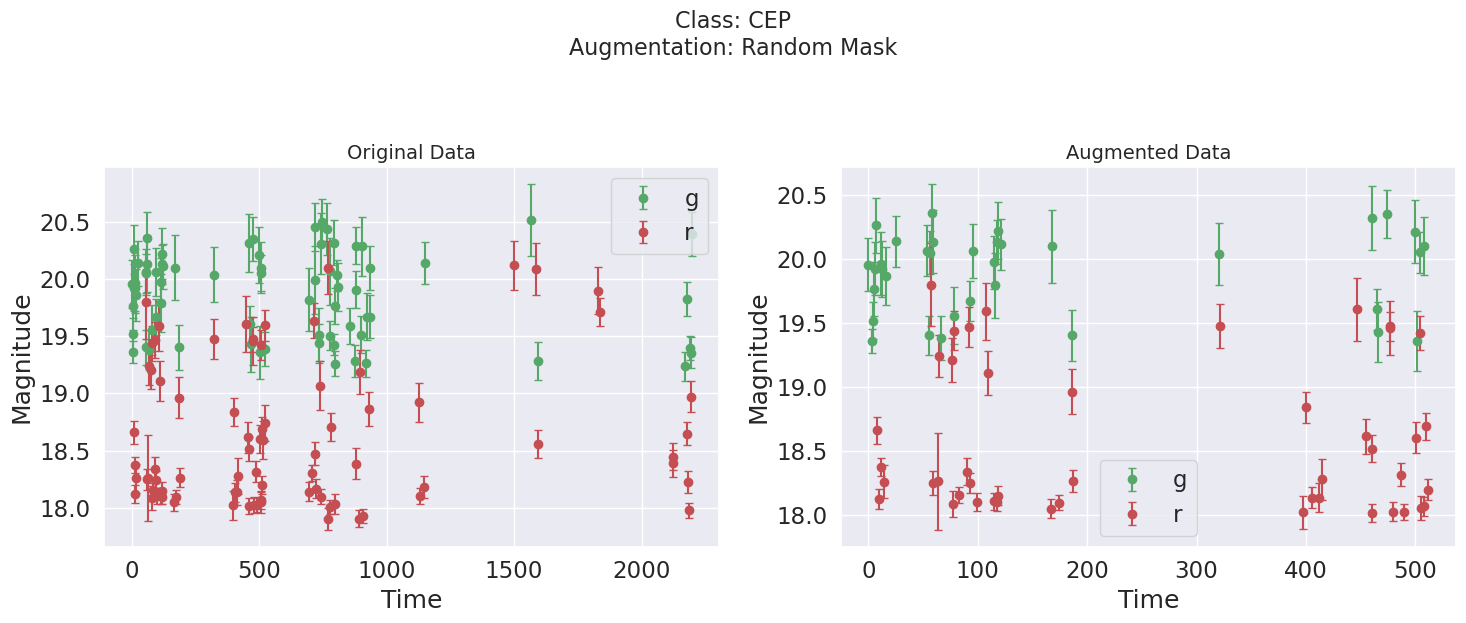

In [337]:
plot_aug(index,random_mask_time,'Random Mask',fold=False)

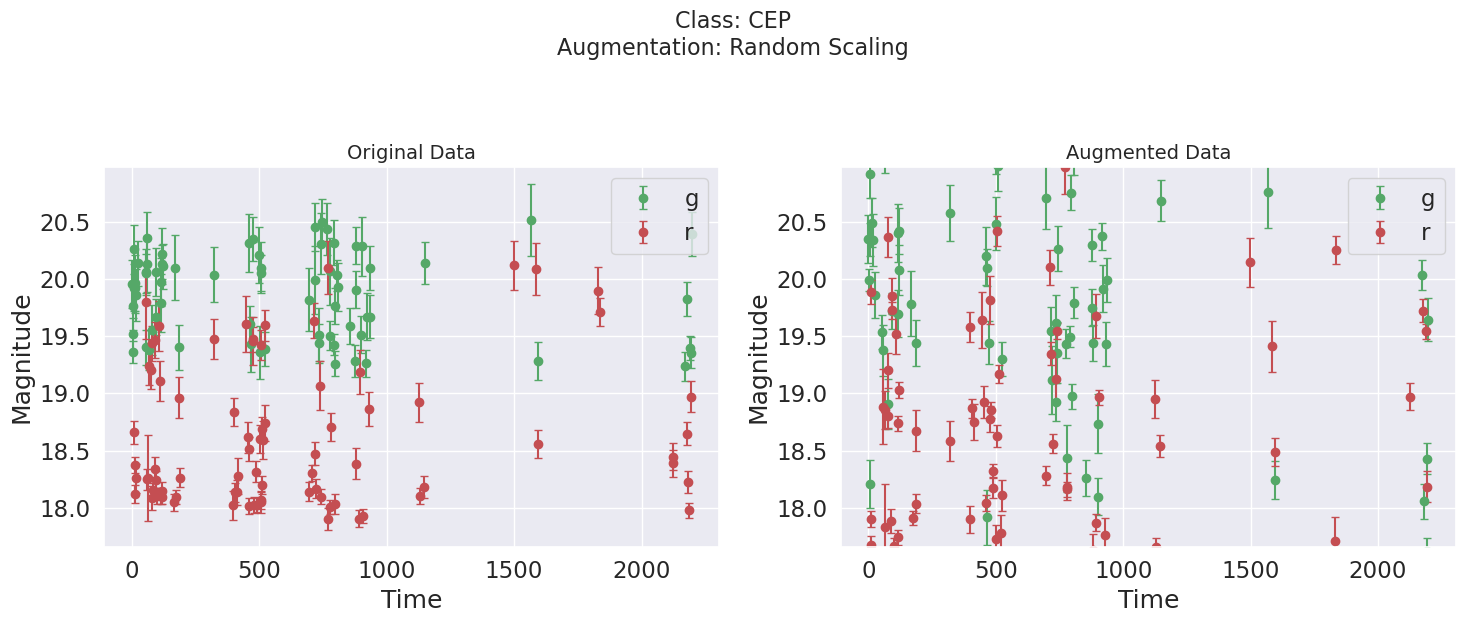

In [338]:
plot_aug(index,random_scaling,'Random Scaling',fold=False)

tensor([[ 69,  79],
        [ 68,  78],
        [ 67,  77],
        ...,
        [386, 392],
        [387, 393],
        [388, 394]])
torch.Size([1000, 2])


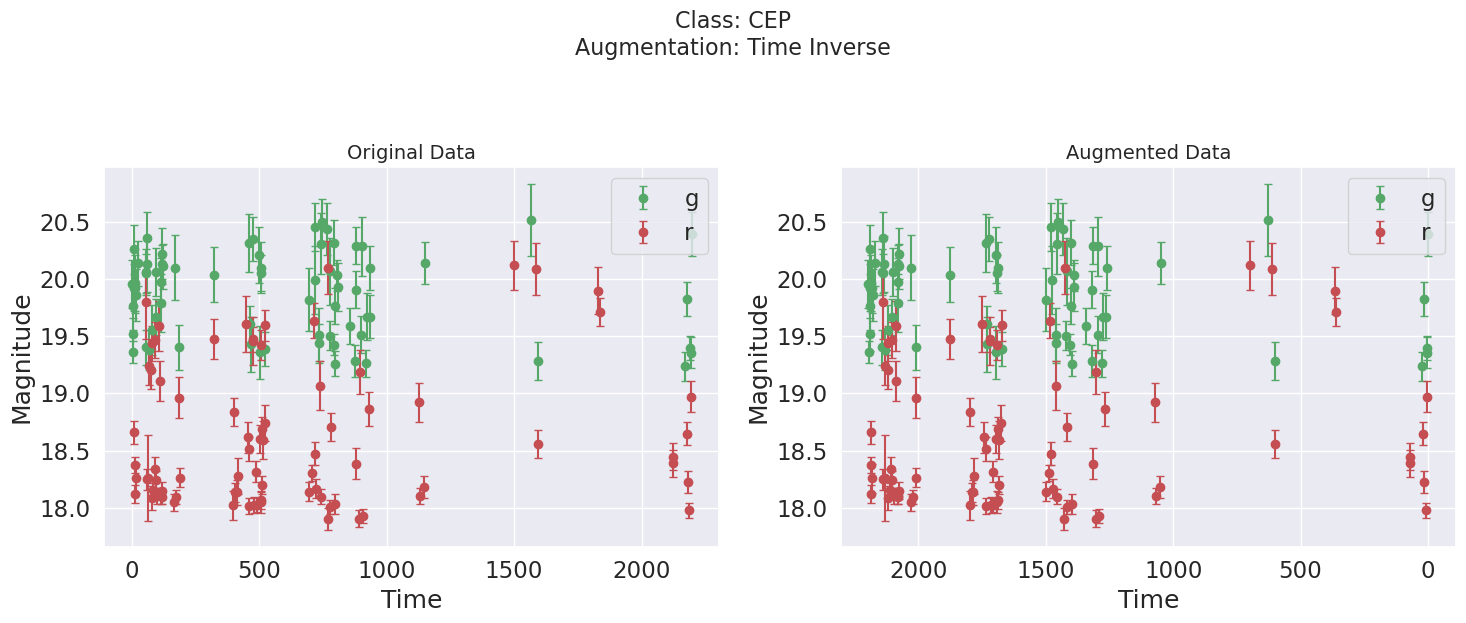

In [339]:
plot_aug(index,time_inverse,'Time Inverse')

In [340]:
def constant_time_warping(time, mag, error, mask,period,scale = 0.05):
    # get a random value between 0.95 and 1.05
    scale = np.random.uniform(1-scale,1+scale)
    print(scale)
    time = torch.from_numpy(time)
    mag = torch.from_numpy(mag)
    error = torch.from_numpy(error)
    mask = torch.from_numpy(mask)  # Convert mask to boolean

    #calculate the time difference between each point
    time = time * scale

    period = period * scale
    
    return time.numpy(), mag.numpy(), error.numpy(), mask.numpy(),period

0.950996934193892


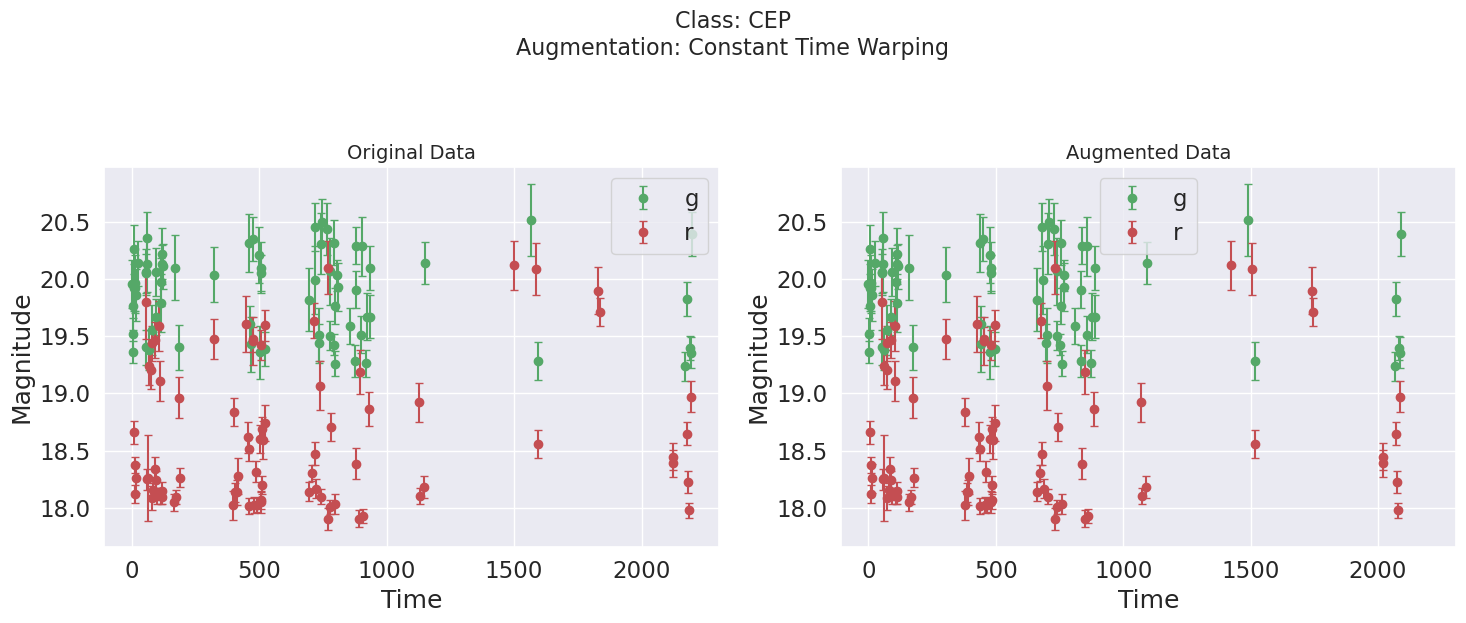

In [366]:
plot_aug(index,constant_time_warping,'Constant Time Warping',fold=False)

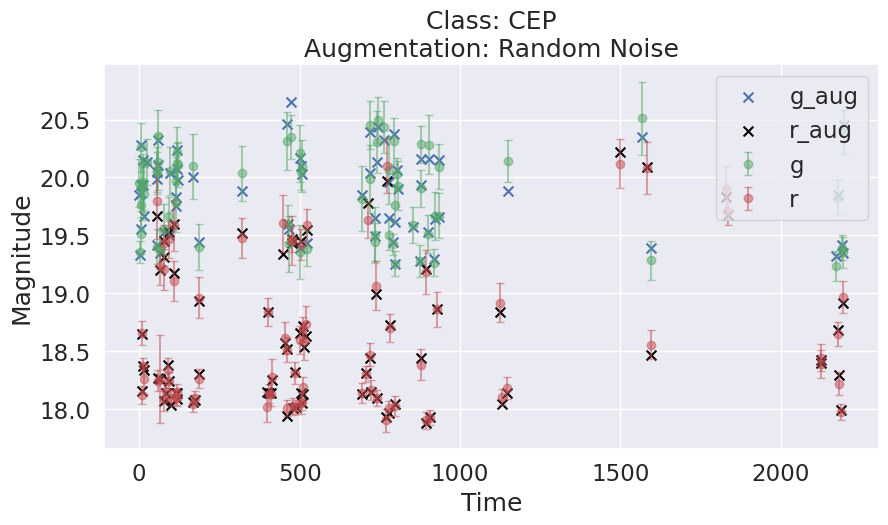

In [342]:
plot_aug(index,random_noise,'Random Noise')

tensor([[ 69,  79],
        [ 68,  78],
        [ 67,  77],
        ...,
        [386, 392],
        [387, 393],
        [388, 394]])
torch.Size([1000, 2])


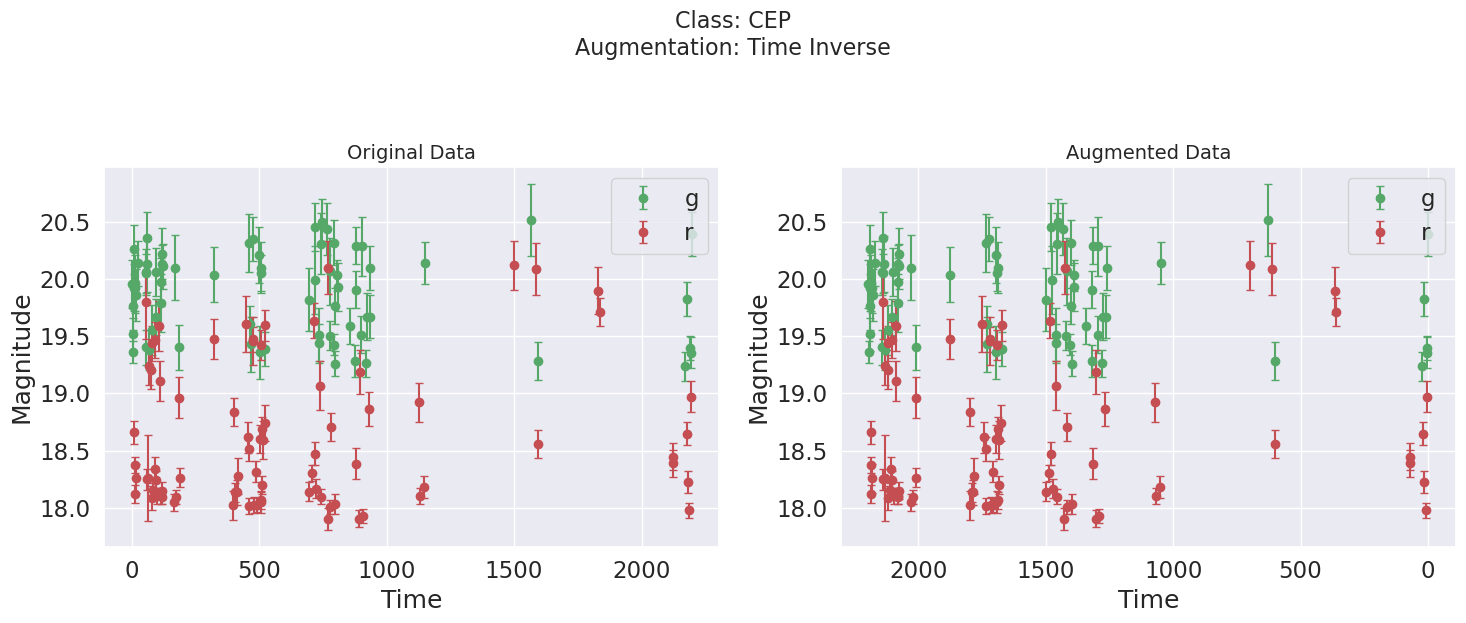

In [343]:
plot_aug(index,time_inverse,'Time Inverse')

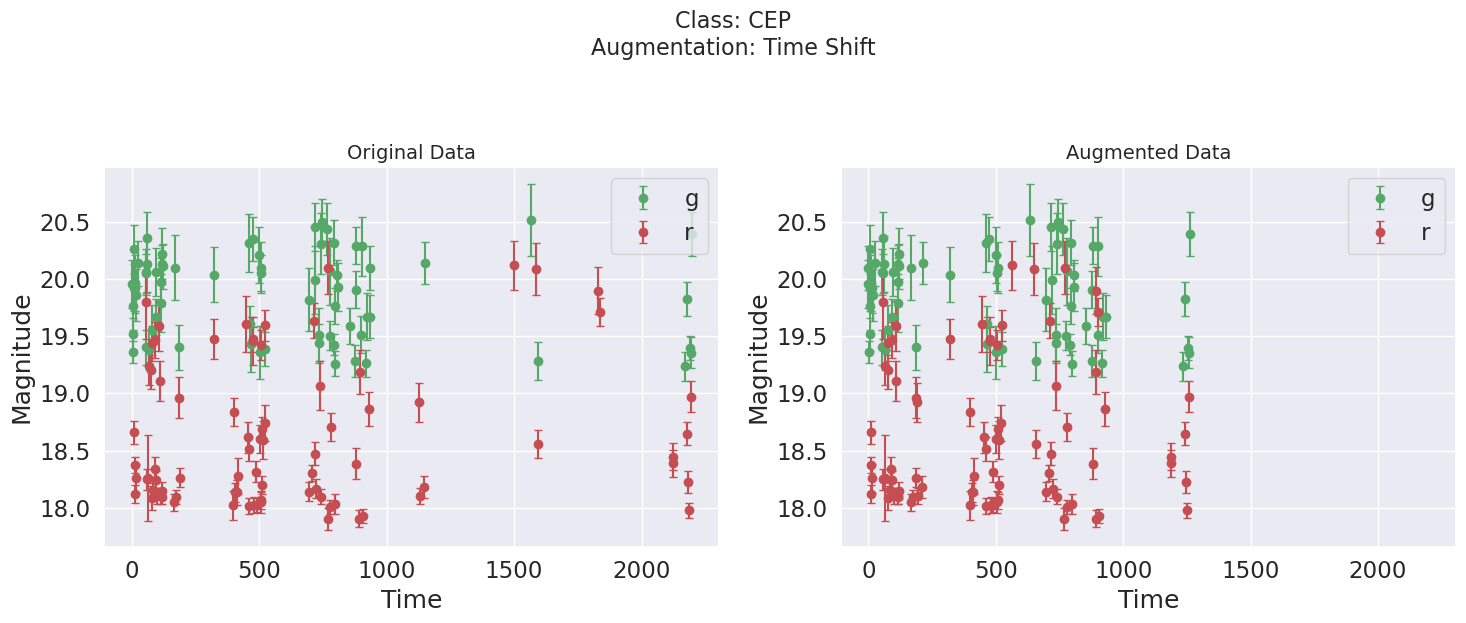

In [344]:
plot_aug(index,time_shift,'Time Shift',fold=False)

In [345]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [346]:
results = pd.read_csv('/home/fsoto/Documents/LCsSSL/logs/train/multiruns/myself_linear_augmentation_test_v3/results.csv')

In [347]:
#select the columns with name 'test/f1' in the results dataframe
results_f1 = results.filter(regex='test/f1')

In [348]:

list_of_augs = ['Random Mask', 'Random Scaling', 'Random Noise', 'Time Shift', 'Time Inverse', 'Time Warping']

In [349]:
combinations = [(aug, aug_2) for aug in list_of_augs for aug_2 in list_of_augs]
df = pd.DataFrame(combinations, columns=['aug', 'aug_2'])


In [350]:
df

,aug,aug_2
0,Random Mask,Random Mask
1,Random Mask,Random Scaling
2,Random Mask,Random Noise
3,Random Mask,Time Shift
4,Random Mask,Time Inverse
5,Random Mask,Time Warping
6,Random Scaling,Random Mask
7,Random Scaling,Random Scaling
8,Random Scaling,Random Noise
9,Random Scaling,Time Shift


In [351]:

df_total = df.reset_index(drop=True)

In [352]:
#concatenate results_total and df_total
results_total = pd.concat([results_f1,df_total],axis=1)

In [353]:
results_total= results_total.reset_index(drop=True)

In [354]:
results_total

,test/f1,aug,aug_2
0,0.297260,Random Mask,Random Mask
1,0.430687,Random Mask,Random Scaling
2,0.397927,Random Mask,Random Noise
3,0.481437,Random Mask,Time Shift
4,0.507519,Random Mask,Time Inverse
5,0.411312,Random Mask,Time Warping
6,0.415628,Random Scaling,Random Mask
7,0.303920,Random Scaling,Random Scaling
8,0.261463,Random Scaling,Random Noise
9,0.356759,Random Scaling,Time Shift


In [355]:
#get the values of the f1 score and reshape to 6x6
f1_values = results_total['test/f1'].values

In [356]:
reshaped_f1 = f1_values.reshape(6,6)
#for each row in reshaped f1 get the average of the row and append to the list
average_f1 = [row.mean() for row in reshaped_f1] 
average_f1 = np.array(average_f1)
#average over the columns to get the average of the columns



In [357]:
classes = list_of_augs

In [358]:
#sort reshaped f1 by the average f1 rows and columns max to min 

reshaped_f1 = reshaped_f1[average_f1.argsort()[::-1]]
reshaped_f1 = reshaped_f1[:, average_f1.argsort()[::-1]]
classes = np.array(classes)[average_f1.argsort()[::-1]]
average_f1 = average_f1[average_f1.argsort()[::-1]]


In [359]:
mean = reshaped_f1.mean()

In [360]:
#add average f1 to the classes list and reshape f1 to 6x7
classes = np.append(classes,'Average F1')

reshaped_f1 = np.hstack((reshaped_f1,average_f1.reshape(-1,1)))

In [361]:
#mean of 

In [362]:
reshaped_f1.shape

(6, 7)

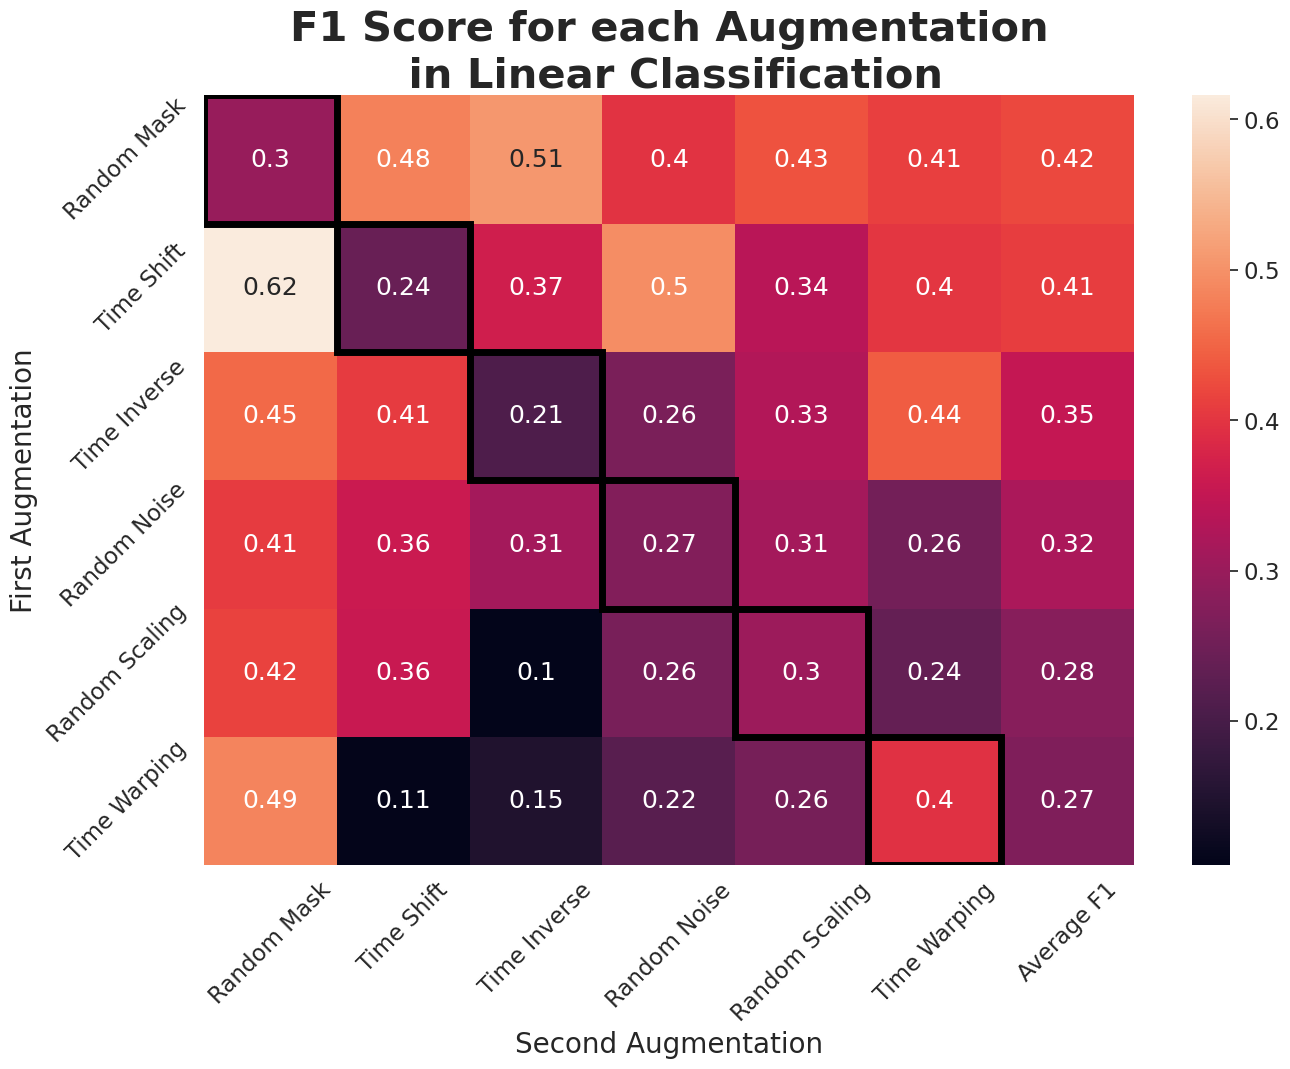

In [363]:
#plot f1 for each class in a confusion matrix
plt.figure(figsize=(15,10))
#make numbers bigger
sns.set(font_scale=1.5)
sns.heatmap(reshaped_f1, annot=True, cbar=True, xticklabels=classes, yticklabels=classes[:6],square=False)
#add border to all the cells in the diagonal

#add a rectangle to the best value 

#make the title bigger
plt.title('F1 Score for each Augmentation\n in Linear Classification', fontsize=30, fontweight='bold')

plt.xlabel('Second Augmentation', fontsize=20)
plt.ylabel('First Augmentation', fontsize=20)
#separete the cells with white lines
for i in range(6):
    plt.gca().add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='Black', lw=5))
#make yticks rotate 45 degrees
plt.yticks(rotation=45)
plt.xticks(rotation=45)
plt.show()

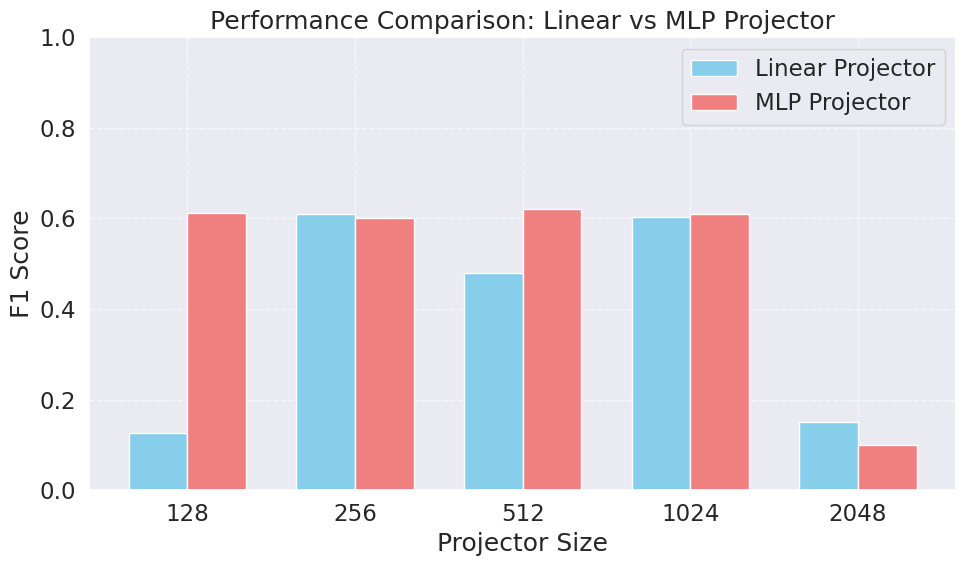

In [364]:
linear_projector = [0.127,0.611,0.48,0.604,0.151]
mlp_projector = [0.613,0.60,0.62,0.61,0.1]
projector_size = [128,256,512,1024,2048]
#plot the f1 score for each class in a bar plot 
# Set the position of bars
x = np.arange(len(projector_size))
width = 0.35  # Width of bars

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
ax.bar(x - width/2, linear_projector, width, label='Linear Projector', color='skyblue')
ax.bar(x + width/2, mlp_projector, width, label='MLP Projector', color='lightcoral')

# Customize plot
ax.set_ylabel('F1 Score')
ax.set_xlabel('Projector Size')
ax.set_title('Performance Comparison: Linear vs MLP Projector')
ax.set_xticks(x)
ax.set_xticklabels(projector_size)
ax.legend()

# Add grid for better readability
ax.grid(True, linestyle='--', alpha=0.7)

# Set y-axis limits
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()